# Analise e Visualização de Dados. Prof.: Leonardo Barbosa


## O que você vai encontrar aqui
- **Como executar o notebook** (pré‑requisitos e ordem de execução).
- **Glossário rápido (PT‑BR)** para termos recorrentes (eventos, tiros/gols, passes, xG, etc.).
- **Boas práticas** para análise reprodutível (ambiente, versões, seeds, estrutura).
- **Dicas de performance** (filtragem, joins, tipos de dados, seleção de colunas).

---

## Como executar
1. **Ambiente**: use Python 3.10+ (ideal) e crie um ambiente virtual (`venv`/`conda`).
2. **Instalação típica**:
   ```bash
   pip install pandas numpy matplotlib seaborn jupyter statsbombpy
   ```
   > Ajuste os pacotes conforme o notebook requer (por exemplo, `mplsoccer`, `plotly`, etc.).
3. **Ordem de execução**: rode as células **de cima para baixo**, sem pular etapas.
4. **Dados**: se o notebook usa `statsbombpy`, é comum fazer **download** local ou usar o **SB API** (quando disponível).
5. **Reprodutibilidade**: fixe seeds quando usar sorteio/amostragem; documente versões de pacotes.

---

## Glossário essencial (PT‑BR)
- **Evento (event)**: ação registrada em campo (passe, finalização, falta, etc.).  
- **xG (Expected Goals)**: probabilidade estimada de um chute virar gol (0 a 1).  
- **xA (Expected Assists)**: contribuição esperada de um passe para gerar finalizações com xG.  
- **Terço final / Zona 14**: áreas do campo usadas em análises táticas/ofensivas.  
- **Pressão / Pressões (pressures)**: eventos de pressão ao portador da bola.  
- **Lances de bola parada (set pieces)**: escanteios, faltas, laterais, pênaltis, etc.

---

## Boas práticas (rápidas)
- **Selecione apenas colunas necessárias** para reduzir memória.  
- **Converta tipos** (por ex. `category` para colunas com rótulos) para acelerar operações.  
- **Normalize** chaves (IDs/nomes) antes de merges/joins.  
- **Documente**: títulos e descrições nas células de Markdown deixam o projeto profissional.

---

## Notas sobre visualização
- Prefira gráficos com **legendas claras**, **unidades** e **rótulos** em PT‑BR.  
- Para mapas de chutes/passes, indique **escala do campo**, **lado de ataque** e **tempo do jogo** se relevante.

---



### Notas rápidas para navegar no notebook
- Sempre que ver uma célula de Markdown em outro idioma, consulte este bloco em PT‑BR.
- Busque por palavras‑chave como **events**, **shots**, **passes**, **lineups**, **competitions** — são conceitos centrais nos dados StatsBomb.
- Se encontrar erros de importação, confirme as versões dos pacotes e a existência de credenciais (quando o notebook usa APIs).

In [1]:
#instalando libs necesarias
!pip install statsbombpy
!pip install mplsoccer
!pip install highlight_text

In [2]:
#importando libs necessárias
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from highlight_text import ax_text, fig_text
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

In [3]:
'''
Manipulação de dados
'''
#Tabela das competições abertas do StatsBomb
free_comps = sb.competitions()
free_comps

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [4]:
#Competição Selecionada
weuro_2025 = sb.matches(competition_id=53, season_id=315)
weuro_2025.head(5) # Exibir as 5 primeiras linhas

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,4020846,2025-07-27,16:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Spain Women's,1,1,available,...,2025-07-29T16:03:07.355174,6,Final,St. Jakob-Park,Stéphanie Frappart,Sarina Glotzbach-Wiegman,Montserrat Tomé Vázquez,1.1.0,2,2
1,4020077,2025-07-23,19:00:00.000,Europe - UEFA Women's Euro,2025,Germany Women's,Spain Women's,0,1,available,...,2025-07-25T15:22:27.432293,5,Semi-finals,Stadion Letzigrund,Edina Alves Batista,Christian Richard Wück,Montserrat Tomé Vázquez,1.1.0,2,2
2,4020005,2025-07-22,19:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Italy Women's,2,1,available,...,2025-07-24T13:46:36.152311,5,Semi-finals,Stade de Genève,Ivana Martinčić,Sarina Glotzbach-Wiegman,Andrea Soncin,1.1.0,2,2
3,4018357,2025-07-19,19:00:00.000,Europe - UEFA Women's Euro,2025,France Women's,Germany Women's,1,1,available,...,2025-07-20T21:36:08.622324,4,Quarter-finals,St. Jakob-Park,Tess Olofsson,Laurent Pierre Bonadéi,Christian Richard Wück,1.1.0,2,2
4,4018356,2025-07-18,19:00:00.000,Europe - UEFA Women's Euro,2025,Spain Women's,Switzerland Women's,2,0,available,...,2025-07-19T21:26:11.543565,4,Quarter-finals,Stadion Wankdorf,Maria Sole Ferrieri Caputi,Montserrat Tomé Vázquez,Pia Mariane Sundhage,1.1.0,2,2


In [5]:
#Filtramos os dados da Inglaterra
partidas_inglaterra = weuro_2025.loc[(weuro_2025['home_team'] == "England Women's")|(weuro_2025['away_team'] == "England Women's")]
partidas_inglaterra

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,4020846,2025-07-27,16:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Spain Women's,1,1,available,...,2025-07-29T16:03:07.355174,6,Final,St. Jakob-Park,Stéphanie Frappart,Sarina Glotzbach-Wiegman,Montserrat Tomé Vázquez,1.1.0,2,2
2,4020005,2025-07-22,19:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Italy Women's,2,1,available,...,2025-07-24T13:46:36.152311,5,Semi-finals,Stade de Genève,Ivana Martinčić,Sarina Glotzbach-Wiegman,Andrea Soncin,1.1.0,2,2
5,4018355,2025-07-17,19:00:00.000,Europe - UEFA Women's Euro,2025,Sweden Women's,England Women's,2,2,available,...,2025-07-19T15:59:55.422757,4,Quarter-finals,Stadion Letzigrund,Marta Huerta de Aza,Peter Gerhardsson,Sarina Glotzbach-Wiegman,1.1.0,2,2
7,3998858,2025-07-13,19:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Wales,6,1,available,...,2025-07-14T16:47:58.593247,3,Group Stage,Kybunpark,Frida Mia Klarlund Nielsen,,,None,None,None
15,3998851,2025-07-09,16:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Netherlands Women's,4,0,available,...,2025-07-10T14:29:47.046613,2,Group Stage,Stadion Letzigrund,Edina Alves Batista,Sarina Glotzbach-Wiegman,Andries Jonker,1.1.0,2,2
25,3998843,2025-07-05,19:00:00.000,Europe - UEFA Women's Euro,2025,France Women's,England Women's,2,1,available,...,2025-07-06T17:25:37.441574,1,Group Stage,Stadion Letzigrund,Tess Olofsson,Laurent Pierre Bonadéi,Sarina Glotzbach-Wiegman,1.1.0,2,2


In [ ]:
# Opção para visualizar todas as colunas
pd.options.display.max_columns = None
# Opção para visualizar todas as linhas
pd.options.display.max_rows = None

In [6]:
# Eventos de uma partida especifica 
final = sb.events(match_id= 4020846)
final.head(2)

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England Women's,865,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Spain Women's,863,00:00:00.000,Starting XI,NaN


In [7]:
#Para ver quais são os nomes das colunas que a nossa base de dados possui e saber o que nos interessa analisar
final.columns.to_list()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_outcome',
 'pass_outswinging',
 'pa

In [8]:
# Filtrando apenas as ações do tipo 'Passe' na partida específica 
# Para ver quais outros tipos de ações existem, posso utilizar final['type'].unique()
final['type'].unique()
passes = final[final['type']=='Pass']

In [ ]:
final['type'].unique()

In [10]:
#Aqui está os famosos dados cood. X e Y
passes['location']

12       [61.0, 40.1]
13       [28.5, 43.8]
14       [83.6, 59.0]
15       [91.8, 69.5]
16        [11.1, 0.1]
            ...      
1313    [103.8, 55.7]
1314     [96.2, 56.2]
1315    [104.5, 63.1]
1316    [111.6, 64.2]
1317    [105.2, 76.3]
Name: location, Length: 1306, dtype: object

In [11]:
# Separando a coluna onde estão as coordenadas x,y juntas em colunas separadas
# Primeiro, criamos novas colunas 'x' e 'y' e as preenchemos separando as coordenadas da coluna 'location'
# Segundo, criamos as colunas 'x' e 'y' das coordenadas onde o passe termina e as preenchemos separando 'pass_end_location'

passes[['x', 'y']] = passes['location'].apply(pd.Series)
passes[['pass_end_x', 'pass_end_y']] = passes['pass_end_location'].apply(pd.Series)
passes.head(2)

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_16188\295019945.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes[['x', 'y']] = passes['location'].apply(pd.Series)
C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_16188\295019945.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes[['x', 'y']] = passes['location'].apply(pd.Series)
C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_16188\295019945.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,...,tactics,team,team_id,timestamp,type,under_pressure,x,y,pass_end_x,pass_end_y
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:00.682,Pass,NaN,61.0,40.1,26.4,43.3
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:04.396,Pass,True,28.5,43.8,83.6,59.0


In [12]:
# Separando em diferentes tabelas os passes da Inglaterra e os da Espanha
passes_inglaterra=passes[(passes["team"]=="England Women's")]
pases_espanha = passes[(passes["team"]=="Spain Women's")]
passes_inglaterra.head(2)

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,...,tactics,team,team_id,timestamp,type,under_pressure,x,y,pass_end_x,pass_end_y
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:00.682,Pass,NaN,61.0,40.1,26.4,43.3
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:04.396,Pass,True,28.5,43.8,83.6,59.0


In [13]:
# Revisar os nomes para saber quais alterar em passes_inglaterra['player']
passes_inglaterra['player'].unique()

array(['Ella Toone', 'Hannah Hampton', 'Lucy Bronze', 'Lauren Hemp',
       'Georgia Stanway', 'Leah Williamson', 'Jessica Carter',
       'Alex Greenwood', 'Lauren James', 'Keira Walsh', 'Alessia Russo',
       'Chloe Kelly', 'Michelle Agyemang', 'Bethany Mead',
       'Niamh Charles', 'Grace Clinton'], dtype=object)

In [14]:
# Alterando o nome das jogadoras para melhor visualização nos gráficos

passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Ella Toone'],'Toone')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Hannah Hampton'],'Hampton')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Lucy Bronze'],'Bronze')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Lauren Hemp'],'Hemp')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Georgia Stanway'],'Stanway')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Leah Williamson'],'William - son')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Jessica Carter'],'Carter')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Alex Greenwood'],'Greenwood')
passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Alessia Russo'],'Russo')


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_16188\1585436209.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Ella Toone'],'Toone')
C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_16188\1585436209.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_inglaterra['player'] = passes_inglaterra['player'].replace(['Hannah Hampton'],'Hampton')
C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_16188\1585436209.py:5: 

In [15]:
passes_inglaterra['player'].unique()

array(['Toone', 'Hampton', 'Bronze', 'Hemp', 'Stanway', 'William - son',
       'Carter', 'Greenwood', 'Lauren James', 'Keira Walsh', 'Russo',
       'Chloe Kelly', 'Michelle Agyemang', 'Bethany Mead',
       'Niamh Charles', 'Grace Clinton'], dtype=object)

In [16]:
#Contando todos os passes da inglaterra
passes_totais = passes_inglaterra.groupby(['player'])['player'].count().to_frame()
passes_totais


,player
player,
Bethany Mead,5
Bronze,66
Carter,51
Chloe Kelly,18
Grace Clinton,2
Greenwood,51
Hampton,57
Hemp,36
Keira Walsh,41


In [17]:
# Separamos os passes completos dos incompletos
# Observamos as diferentes possibilidades de passe utilizando passes_inglaterra['pass_outcome'].unique()
passes_inglaterra['pass_outcome'].unique()


array([nan, 'Incomplete', 'Pass Offside', 'Out', 'Unknown',
       'Injury Clearance'], dtype=object)

In [18]:
#notamos que 'nan' significa completo 
completos = passes_inglaterra[passes_inglaterra['pass_outcome'].isnull()]
incompletos = passes_inglaterra[passes_inglaterra['pass_outcome'].notnull()]
completos.head(10)

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,...,tactics,team,team_id,timestamp,type,under_pressure,x,y,pass_end_x,pass_end_y
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:00.682,Pass,NaN,61.0,40.1,26.4,43.3
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:04.396,Pass,True,28.5,43.8,83.6,59.0
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:07.505,Pass,NaN,83.6,59.0,91.8,69.5
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:09.296,Pass,True,91.8,69.5,95.1,60.9
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:34.601,Pass,NaN,85.3,68.7,84.6,77.9
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:35.817,Pass,True,84.4,76.5,68.9,75.0
21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:37.923,Pass,NaN,68.9,75.0,56.2,48.8
22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:41.146,Pass,NaN,56.2,48.8,56.7,32.6
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:43.060,Pass,True,53.3,36.0,31.8,48.7
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,England Women's,865,00:00:46.243,Pass,NaN,31.8,48.7,46.3,72.6


In [19]:
# Adicionando a contagem dos passes completos e incompletos à nossa tabela de contagem de passes
passes_totais['completos'] = completos.groupby(['player'])['player'].count().to_frame()
passes_totais['incompletos'] = incompletos.groupby(['player'])['player'].count().to_frame()
passes_totais = passes_totais.fillna(0)
passes_totais

,player,completos,incompletos
player,,,
Bethany Mead,5,5,0.0
Bronze,66,40,26.0
Carter,51,45,6.0
Chloe Kelly,18,11,7.0
Grace Clinton,2,2,0.0
Greenwood,51,42,9.0
Hampton,57,31,26.0
Hemp,36,20,16.0
Keira Walsh,41,30,11.0


In [20]:
# Renomeando colunas e criando uma coluna de percentual de passes completos, além de definir um mínimo de passes
passes_totais = passes_totais.rename(columns={'player' : 'passes totais'})
passes_totais = passes_totais.reset_index()
passes_totais['Porcentagem %'] = passes_totais['completos']/passes_totais['passes totais']*100
passes_totais = passes_totais[passes_totais['passes totais']>=10]
passes_totais

,player,passes totais,completos,incompletos,Porcentagem %
1,Bronze,66,40,26.0,60.606061
2,Carter,51,45,6.0,88.235294
3,Chloe Kelly,18,11,7.0,61.111111
5,Greenwood,51,42,9.0,82.352941
6,Hampton,57,31,26.0,54.385965
7,Hemp,36,20,16.0,55.555556
8,Keira Walsh,41,30,11.0,73.170732
9,Lauren James,11,7,4.0,63.636364
13,Stanway,43,35,8.0,81.395349
14,Toone,21,18,3.0,85.714286


In [27]:
'''
Visualizando os Dados
'''
# Você pode criar uma tabela com o top 10 jogadoras separadamente e usar isso no código do gráfico
top_10 = passes_totais.sort_values('Porcentagem %', ascending = False).tail(10)
top_10
# Você pode tentar com .head(10) e a ordem será invertida

,player,passes totais,completos,incompletos,Porcentagem %
14,Toone,21,18,3.0,85.714286
15,William - son,56,47,9.0,83.928571
5,Greenwood,51,42,9.0,82.352941
13,Stanway,43,35,8.0,81.395349
8,Keira Walsh,41,30,11.0,73.170732
9,Lauren James,11,7,4.0,63.636364
3,Chloe Kelly,18,11,7.0,61.111111
1,Bronze,66,40,26.0,60.606061
7,Hemp,36,20,16.0,55.555556
6,Hampton,57,31,26.0,54.385965


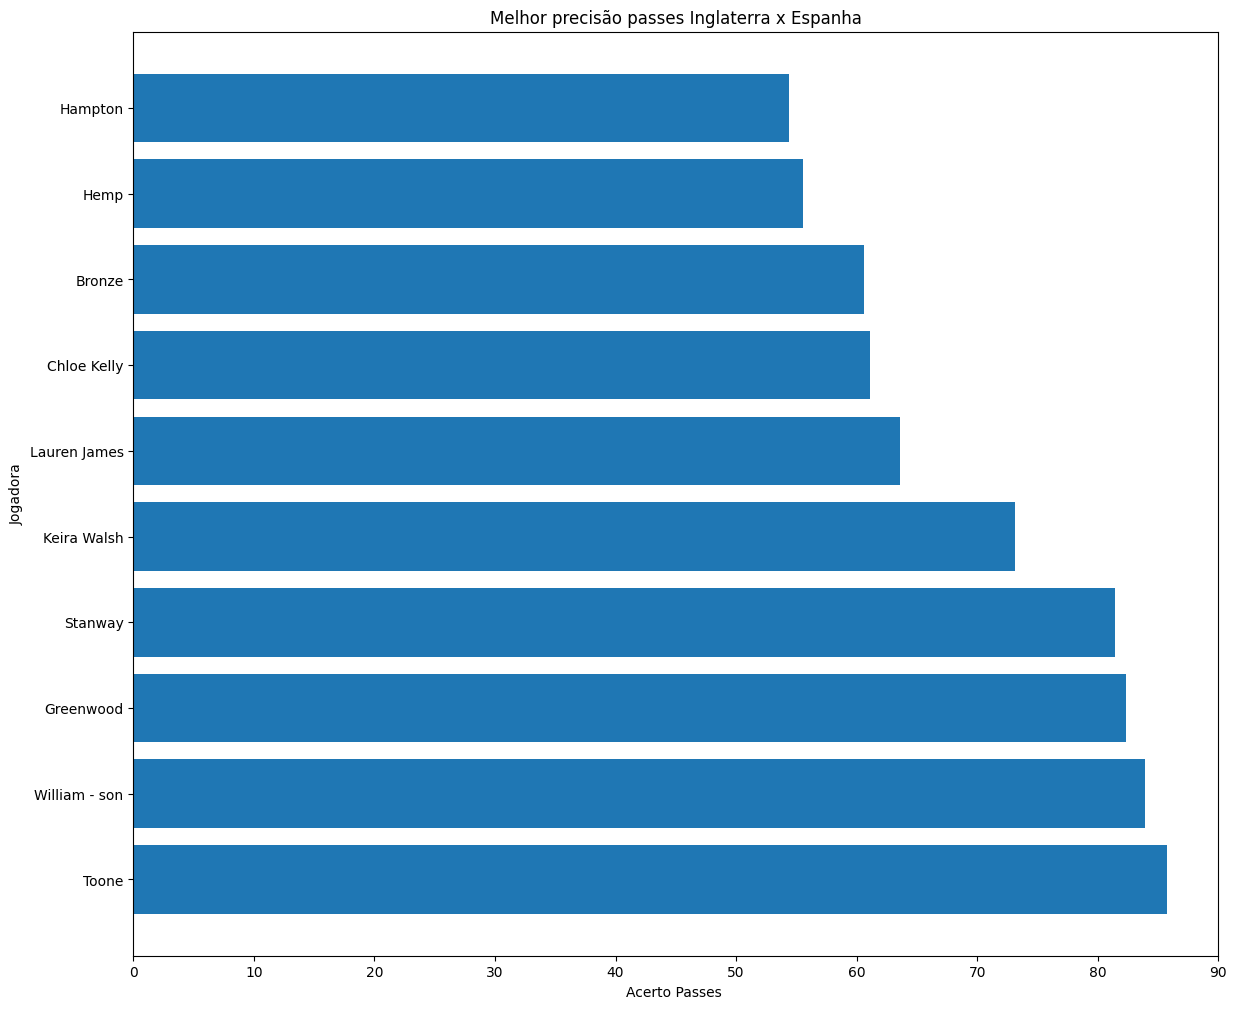

In [28]:
# Gráficos de barras
# Você pode mudar para gráfico vertical utilizando ax.bar em vez de ax.barh (tente!)
fig = plt.figure(figsize=(14, 12))
ax = plt.axes()
ax.barh(top_10['player'],
       top_10['Porcentagem %'])
plt.title("Melhor precisão passes Inglaterra x Espanha")
plt.xlabel("Acerto Passes ")
plt.ylabel("Jogadora")
plt.show()

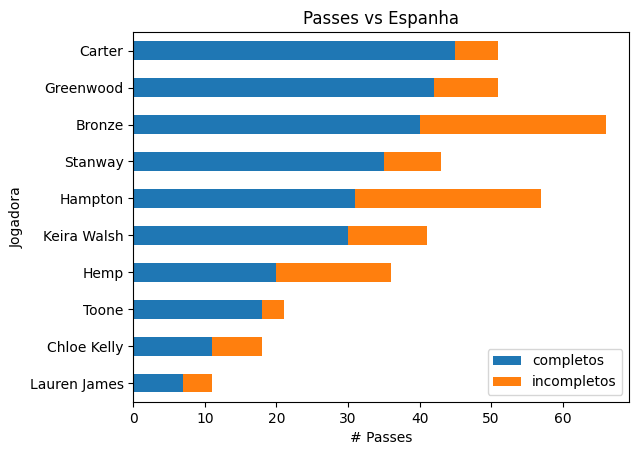

In [29]:
# Para ver duas variáveis de uma mesma categoria no mesmo gráfico, podemos usar 'barras empilhadas' ou 'stack graphs'
# De todos os passes, os completos e incompletos em uma mesma imagem e com duas visualizações diferentes
# stacked = False é opcional dentro de (plot.bar); para ver as barras empilhadas altere para 'bar' para gráfico vertical
ax = passes_totais[['player','completos','incompletos']].sort_values('completos', 
                                 ascending = True).head(10).plot.barh(x='player',stacked=True)
plt.title("Passes vs Espanha")
plt.xlabel("# Passes")
plt.ylabel("Jogadora")
plt.show()

In [30]:
'''
Plotando passes no campo de futebol
'''

# Detalhes das cores das linhas no gráfico
white="white"
sbred='#e21017'
lightgrey="#d9d9d9"
darkgrey='#9A9A9A'
cmaplist = [white, darkgrey, sbred]
cmap = LinearSegmentedColormap.from_list("", cmaplist)

In [31]:
# Criando uma função para gerar o mapa de calor e de passes

def passMap(player):
    
    player = player
    # Filtrando apenas os passes do jogador selecionado
    comp = completos[(completos["player"] == player)]
    incomp = incompletos[(incompletos["player"] == player)]

    # Desenhando o campo de futebol
    pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', line_zorder=2)

    fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
    fig.set_facecolor('white')

    # Contando os passes por zona e coordenadas x & y de finalização dos passes para o mapa de calor
    bin_statistic = pitch.bin_statistic(
        comp.pass_end_x, comp.pass_end_y, statistic='count', bins=(12, 8), normalize=True
    )
    pitch.heatmap(bin_statistic, ax=ax, alpha=0.5, cmap=cmap)

    # Plotando as setas dos passes completados
    pitch.arrows(
        comp.x, comp.y,
        comp.pass_end_x, comp.pass_end_y, width=3,
        headwidth=8, headlength=5, color=sbred, ax=ax, zorder=2, label="Passe certo"
    )

    # Plotando as setas dos passes não completados
    pitch.arrows(
        incomp.x, incomp.y,
        incomp.pass_end_x, incomp.pass_end_y, width=3,
        headwidth=8, headlength=5, color=darkgrey, ax=ax, zorder=2, label="Passe errado"
    )

    # Etiquetas de legenda
    ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

    # Título
    ax_title = ax.set_title(f'Passes de {player} vs Espanha', fontsize=30, color='black')
    
    plt.show()


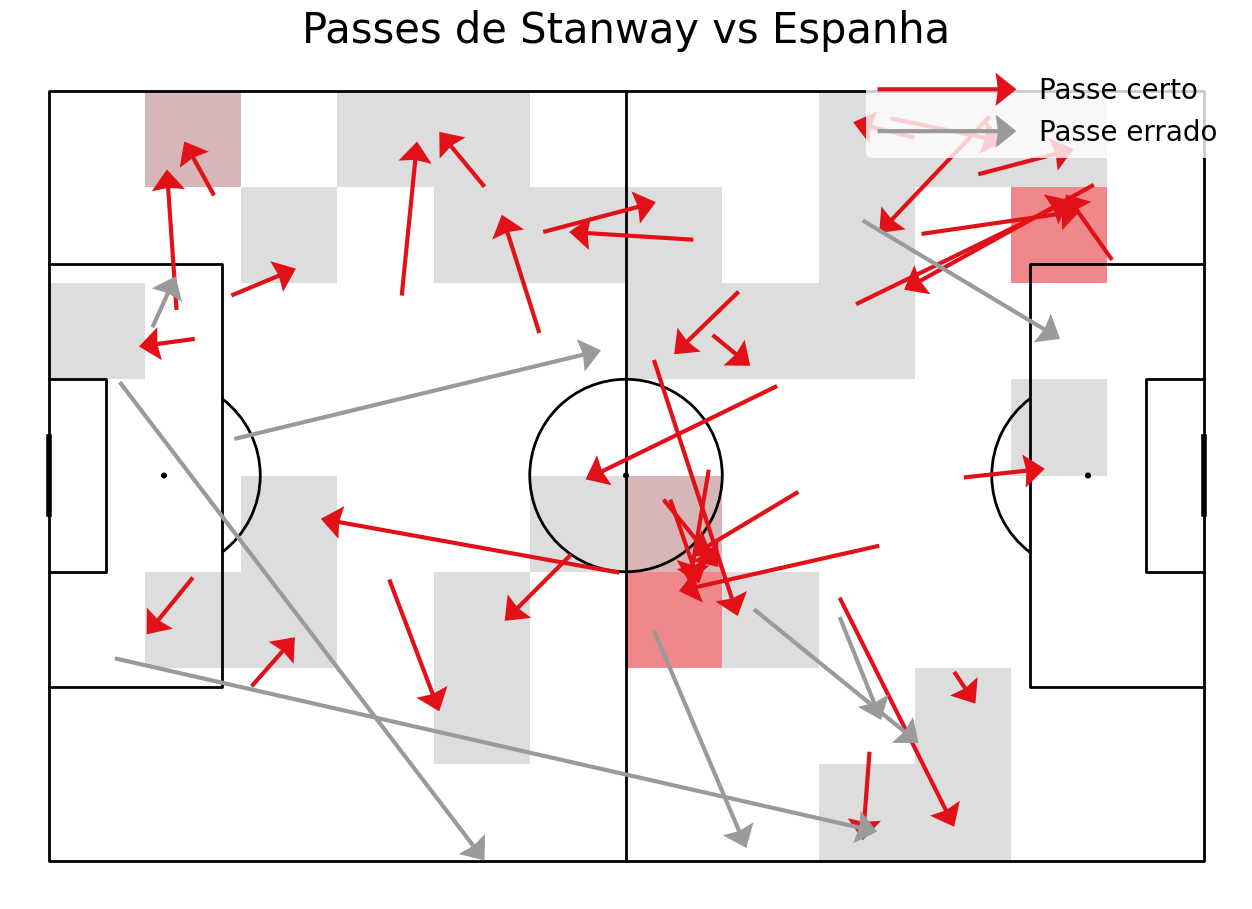

In [33]:
# Escolha a jogadora para analisar; para repetir o mesmo gráfico com outra jogadoras, basta trocar o nome
# tente com: Carter, Toone, William - son, Stanway
passMap('Stanway')

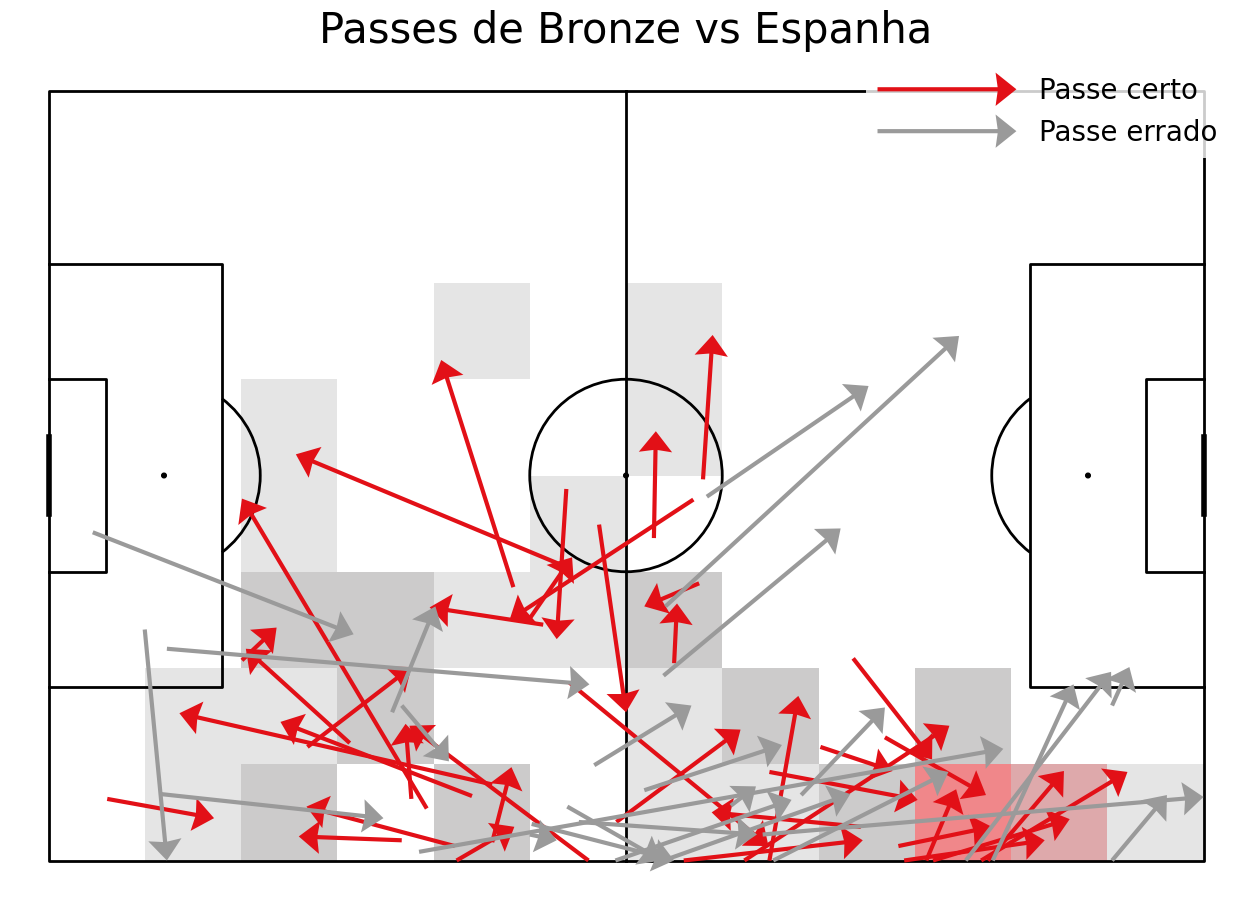

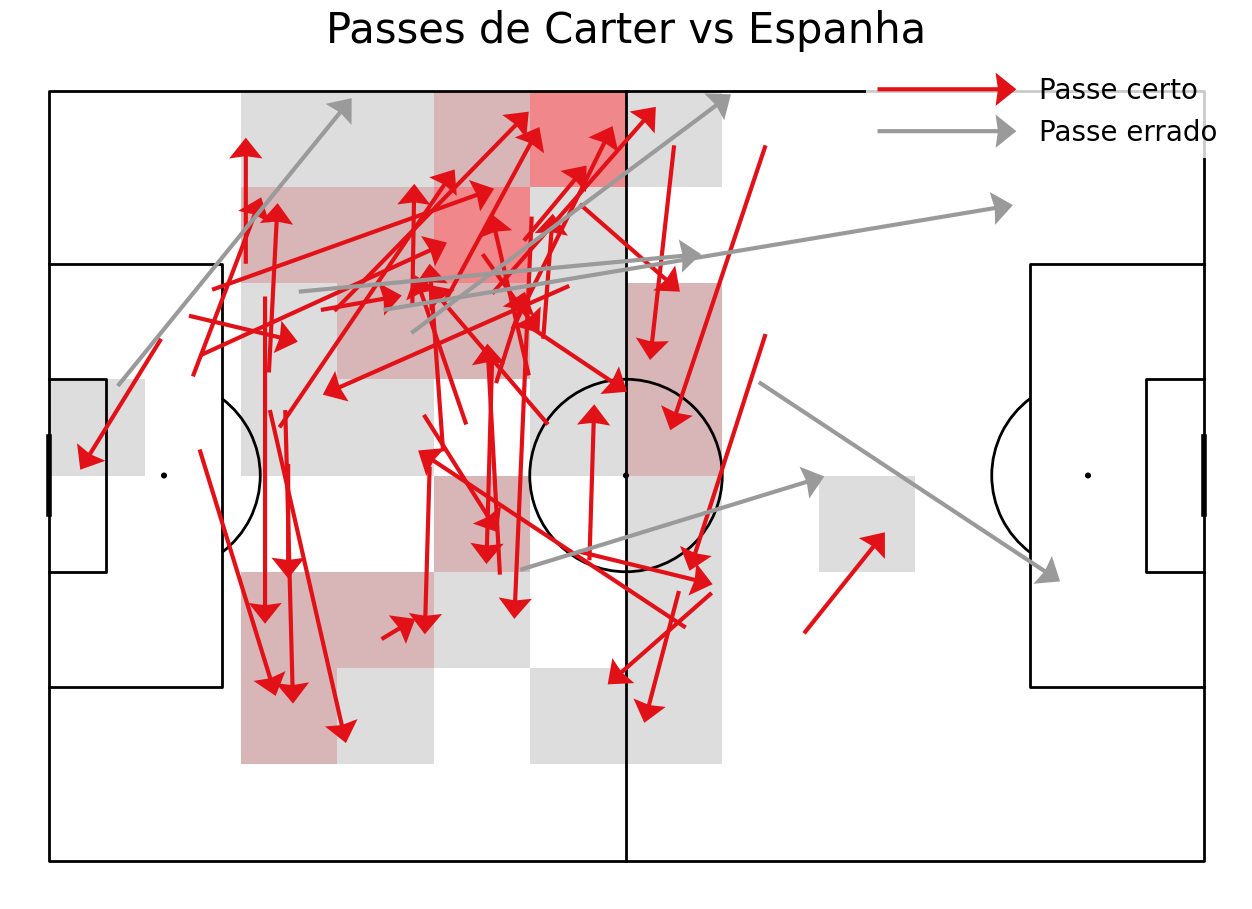

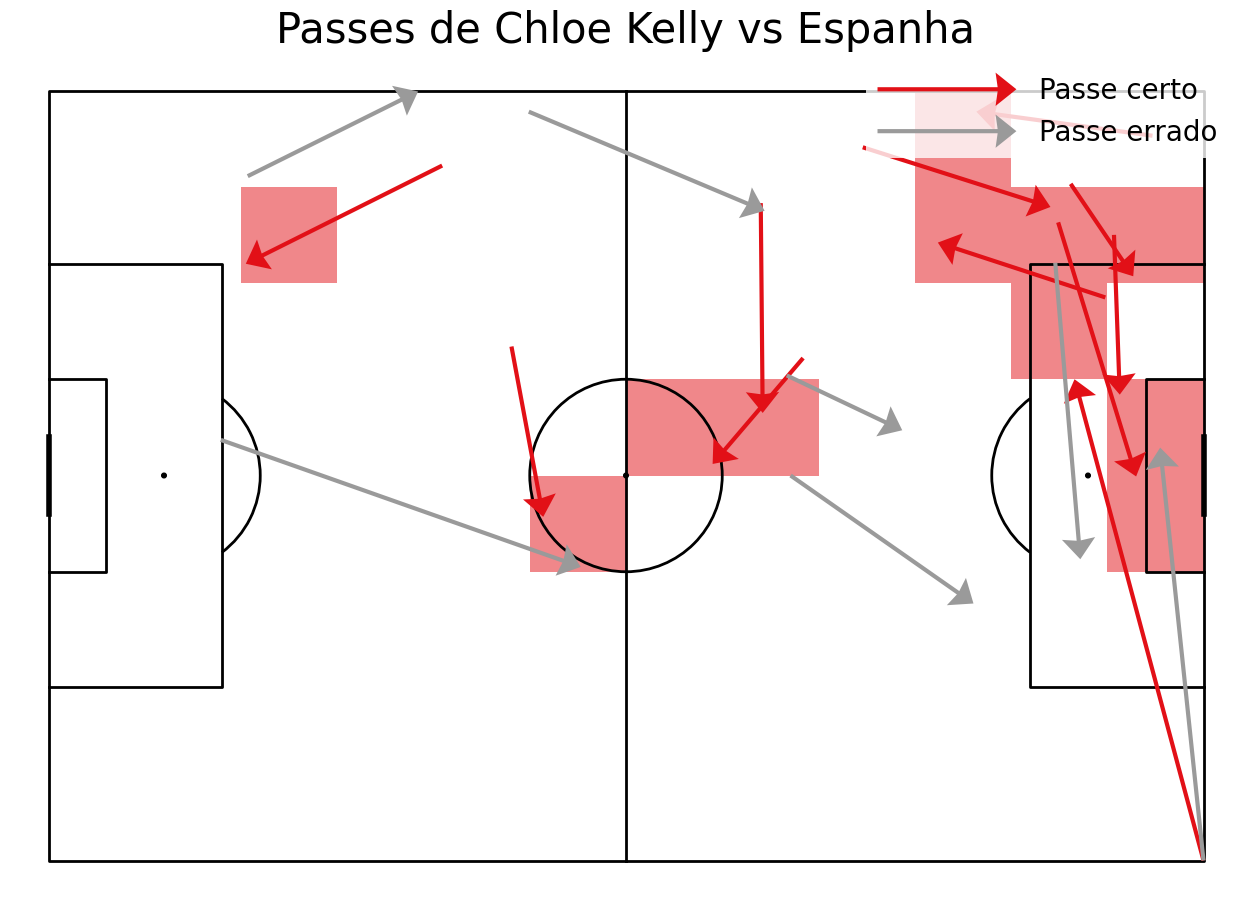

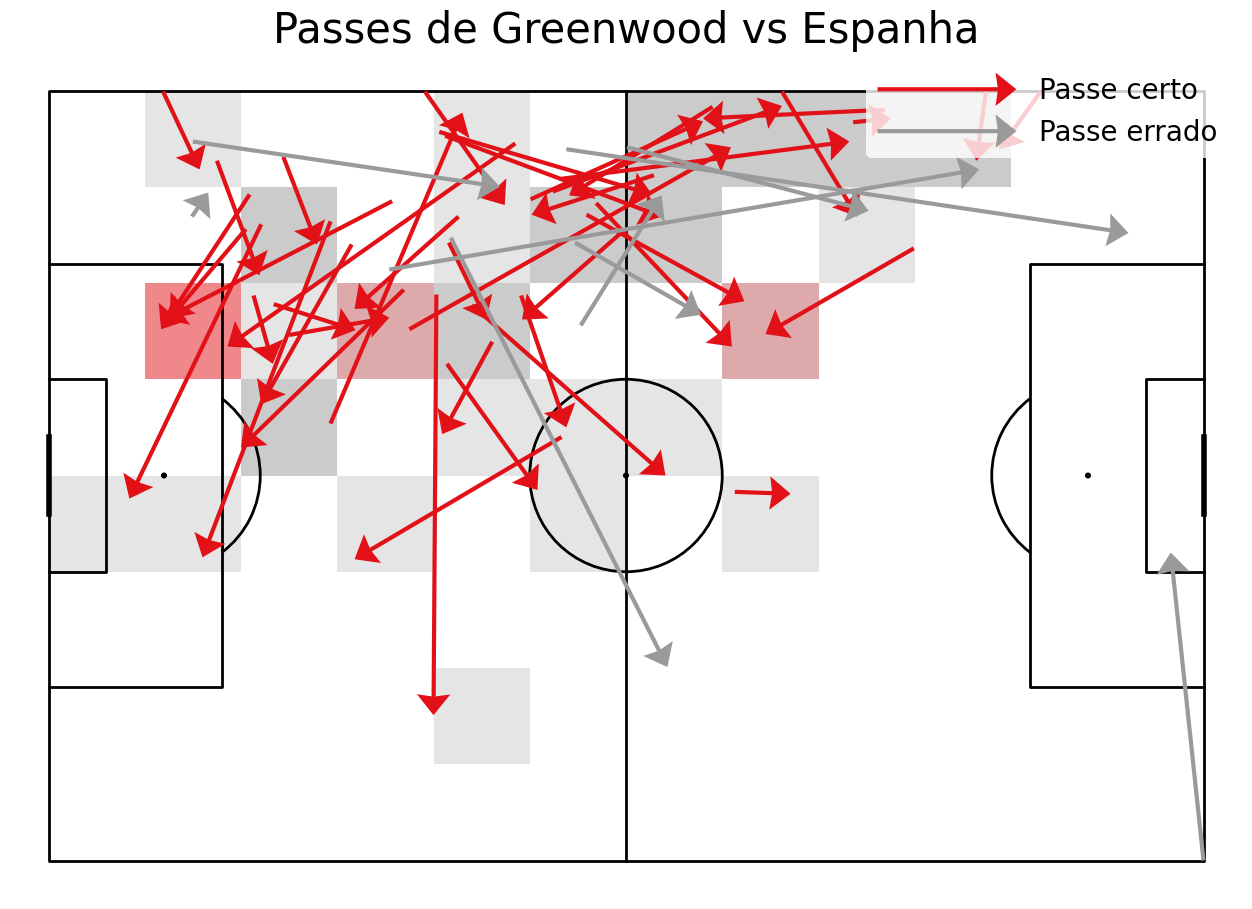

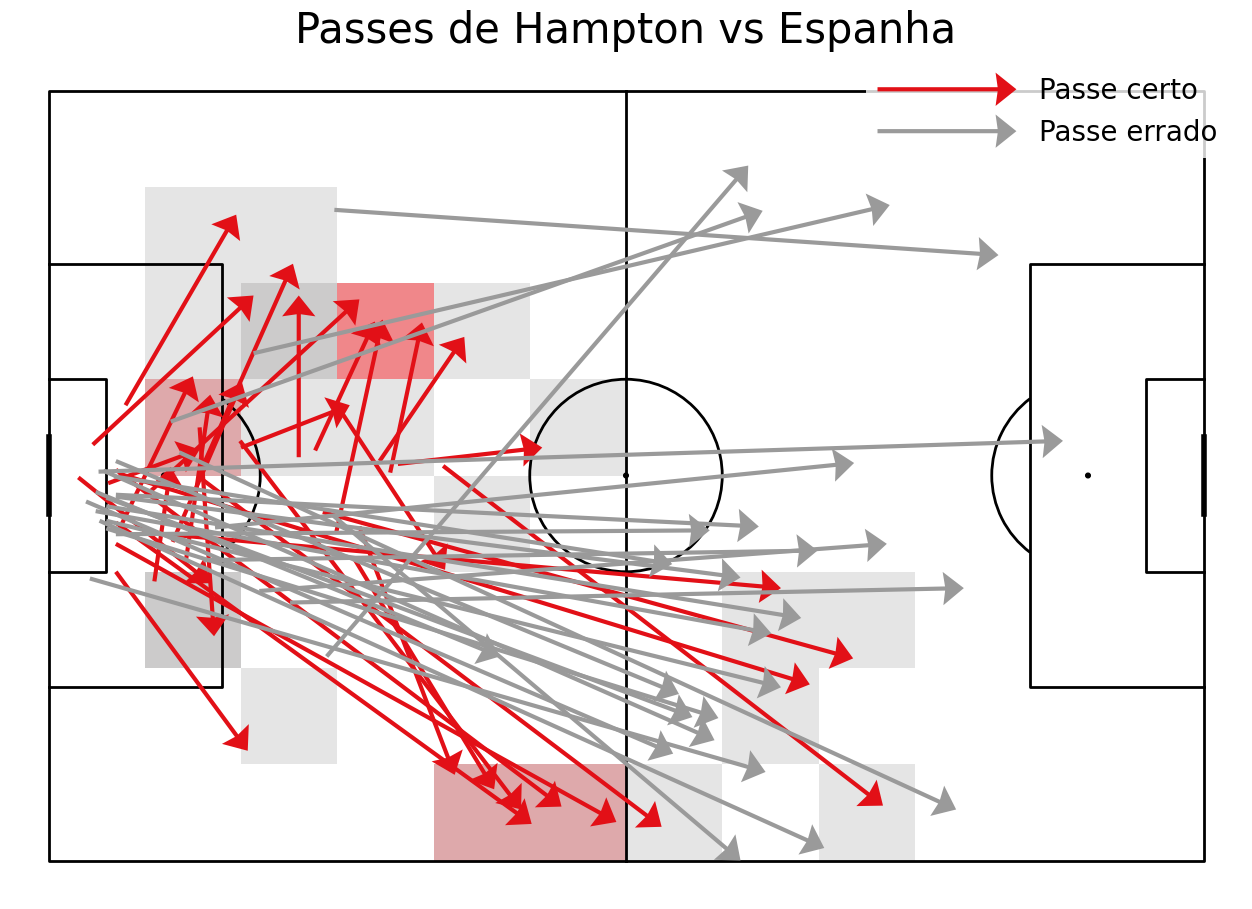

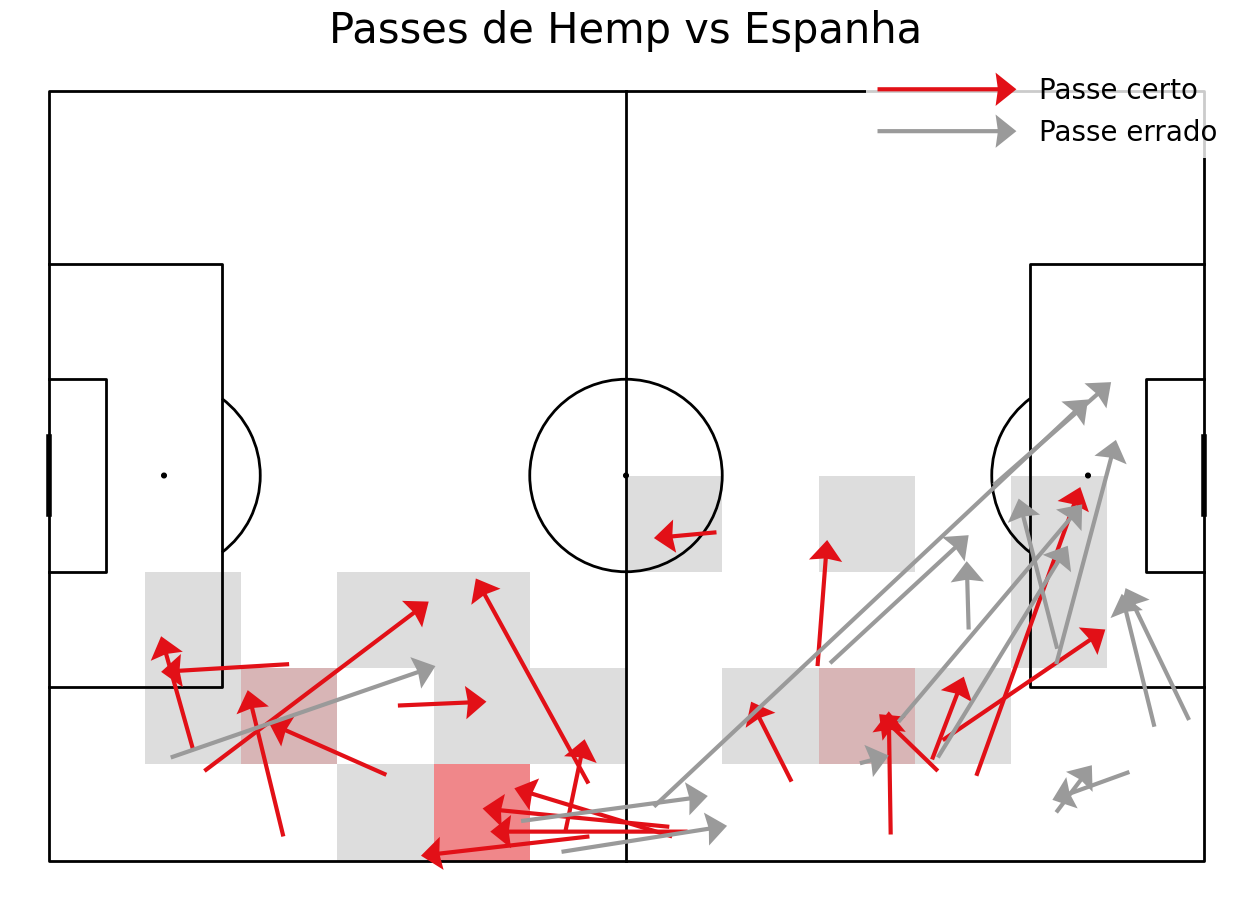

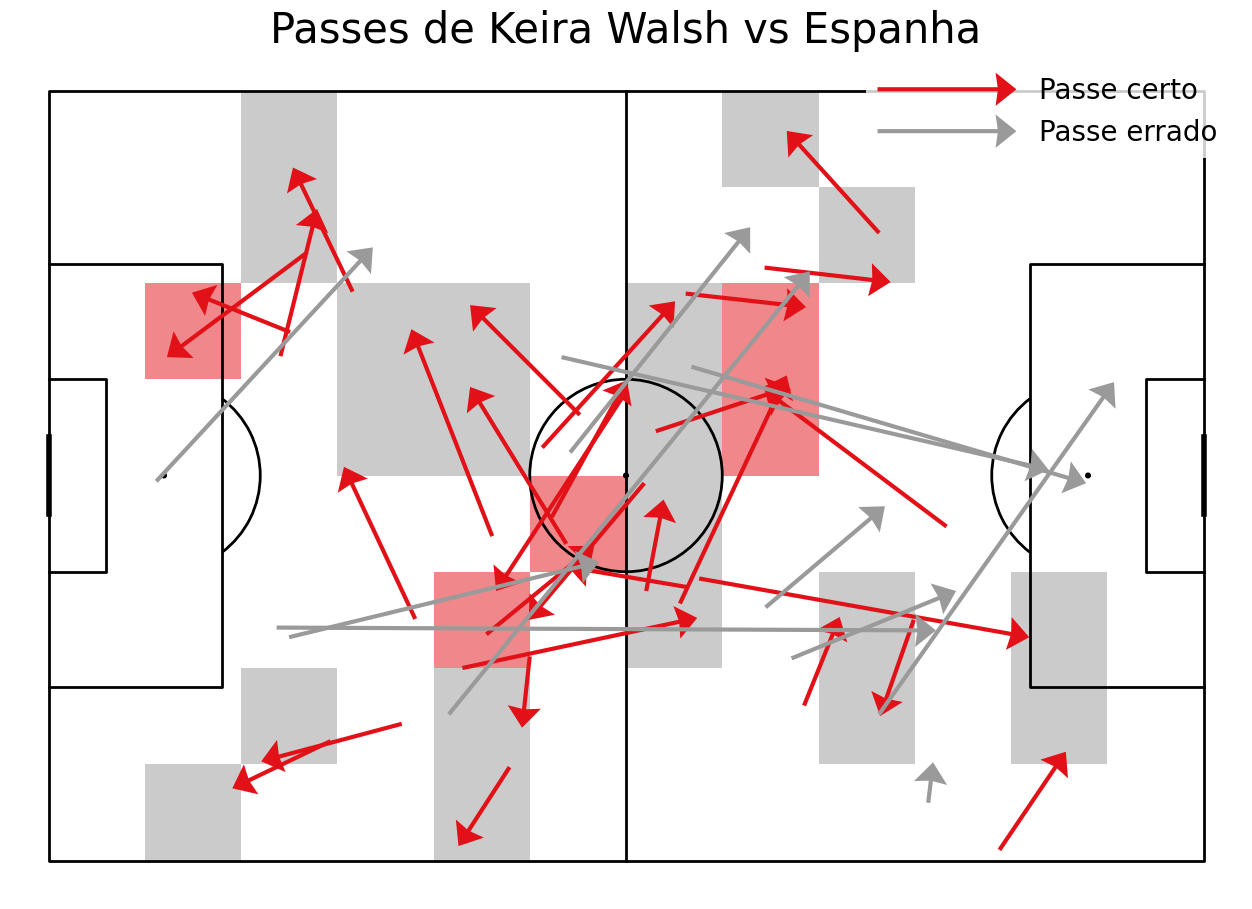

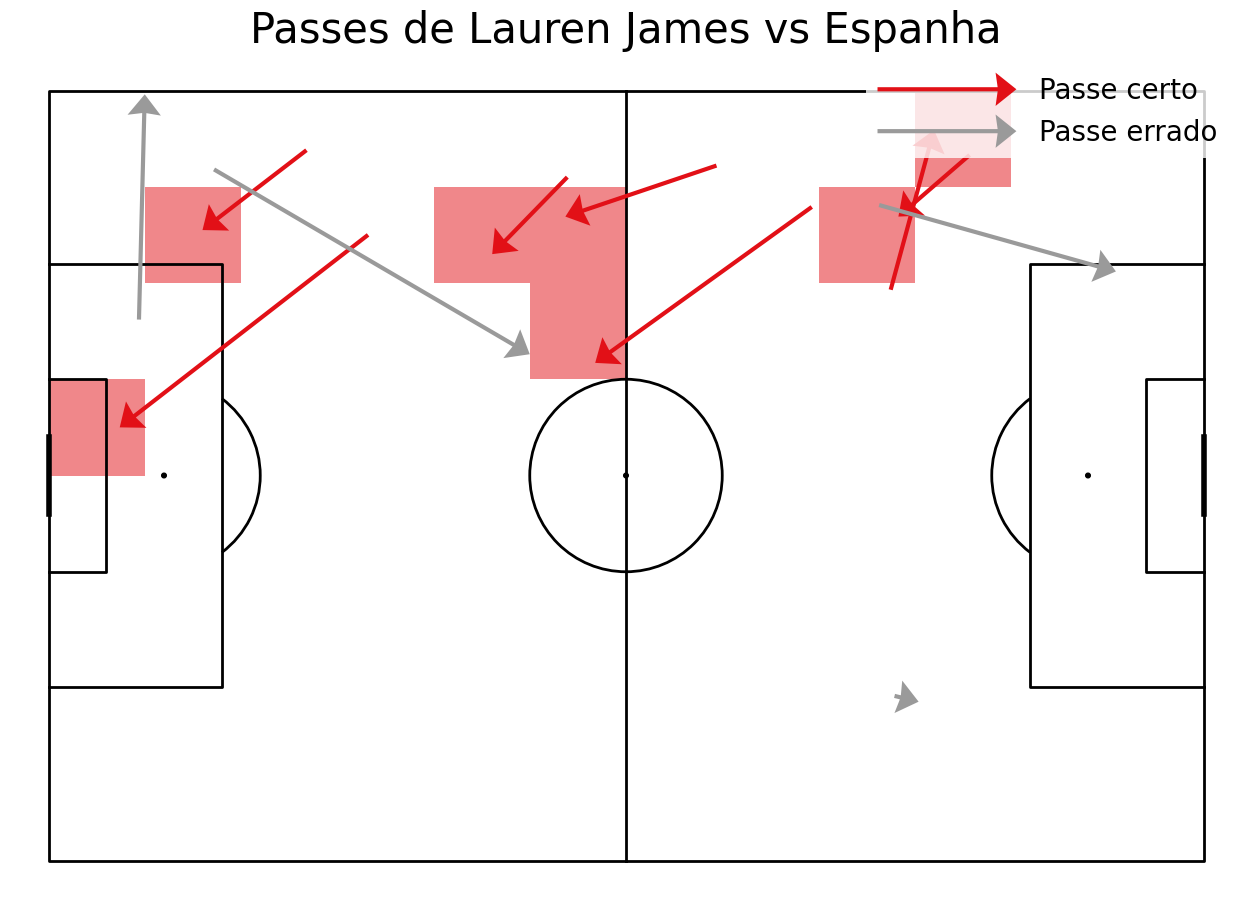

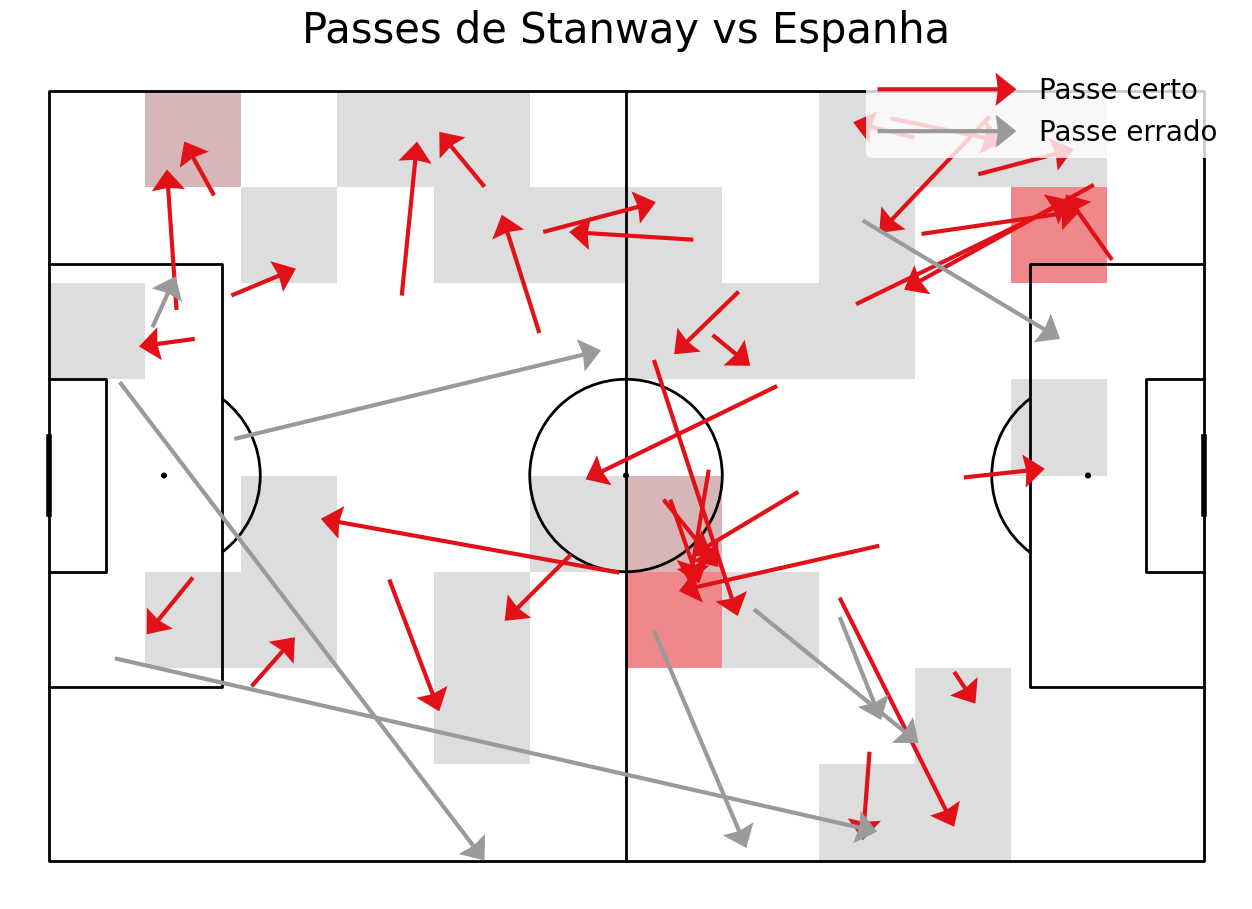

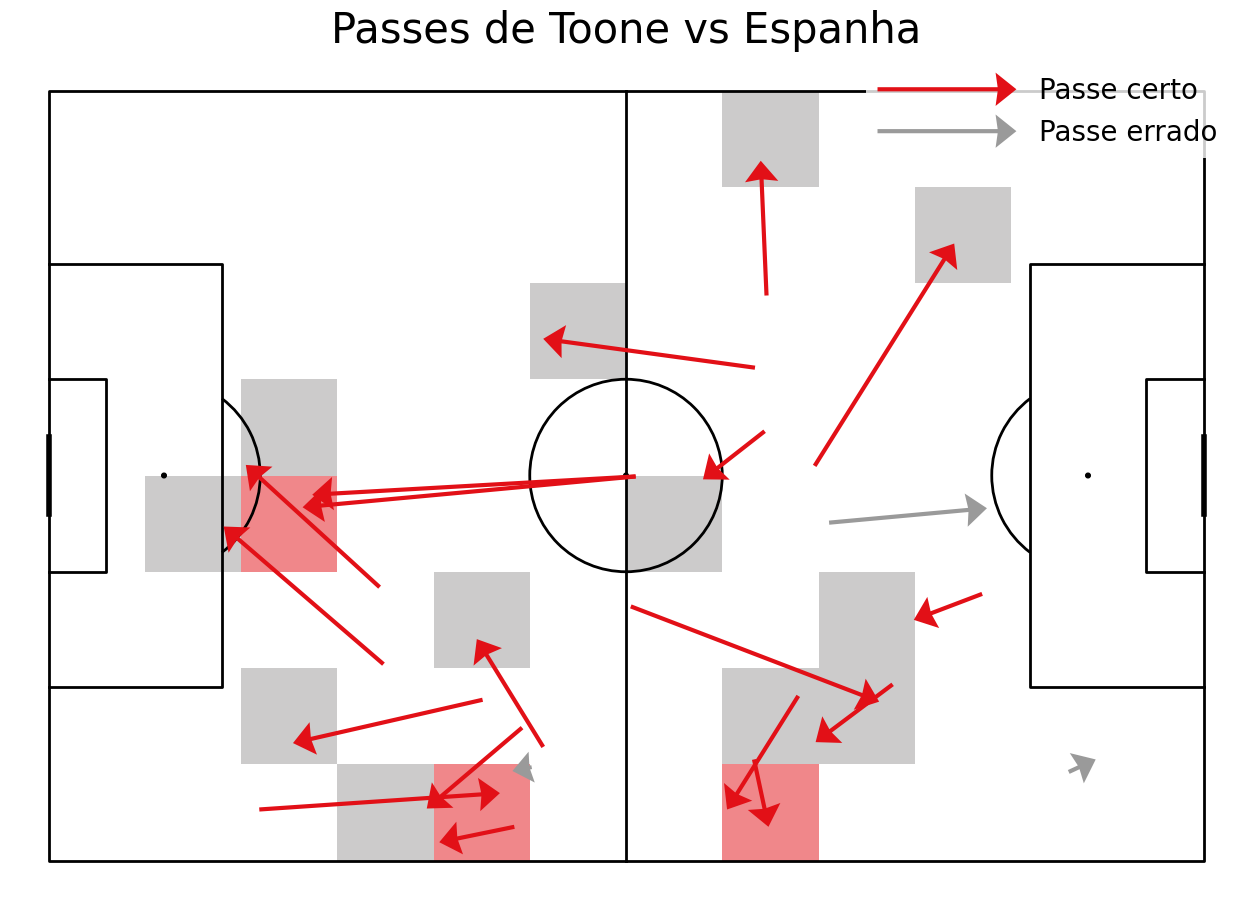

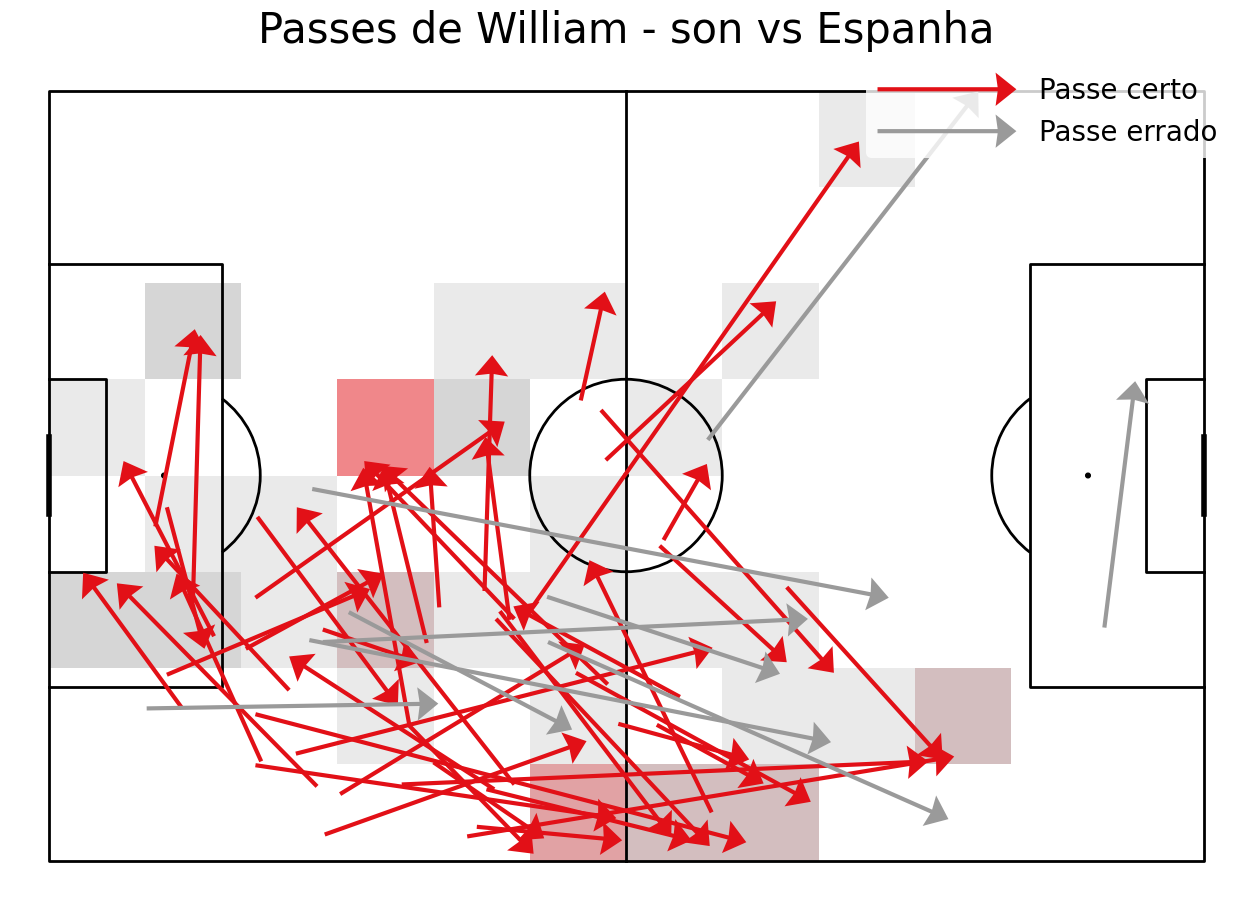

In [34]:
# Para criar o mesmo tipo de mapa para vários jogadores e economizar tempo, você pode usar um 'for loop'
# Você pode utilizar qualquer base de dados onde estejam os nomes dos jogadores que deseja usar
for player in passes_totais['player'].unique():
    passMap(player)

In [35]:
'''
passes para o terço final
'''
# Vamos criar o mesmo tipo de gráfico, mas filtrando a base de dados apenas para passes ao terço final
# Filtrando por coordenadas: passes que começaram antes do terço final e terminaram no terço final


completo_f3 = completos[(completos["pass_end_x"]>=80)]
incompleto_f3 = incompletos[(incompletos["pass_end_x"]>=80)]
completo_f3 = completo_f3[(completo_f3["x"]<80)]
incompleto_f3 = incompleto_f3[(incompleto_f3["x"]<80)]

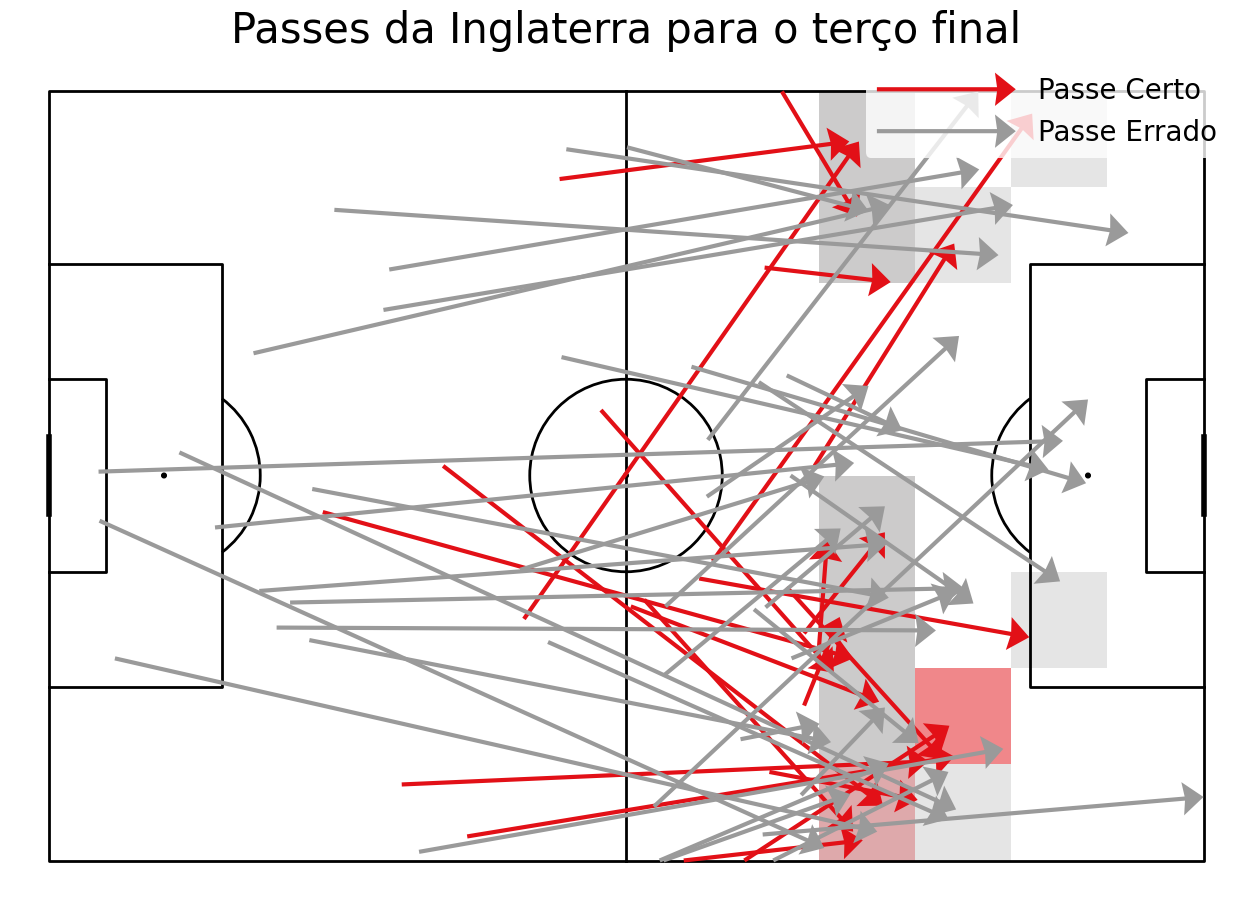

In [36]:
# Desenhando o campo de futebol

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', line_zorder=2)

fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor('white')

# Contagem dos passes completos para o terço final
bin_statistic = pitch.bin_statistic(
    completo_f3.pass_end_x, completo_f3.pass_end_y, statistic='count', bins=(12, 8), normalize=True
)
pitch.heatmap(bin_statistic, ax=ax, alpha=0.5, cmap=cmap)

# Plotando as setas dos passes completos
pitch.arrows(
    completo_f3.x, completo_f3.y,
    completo_f3.pass_end_x, completo_f3.pass_end_y, width=3,
    headwidth=8, headlength=5, color=sbred, ax=ax, zorder=2, label="Passe Certo"
)

# Plotando as setas dos passes incompletos
pitch.arrows(
    incompleto_f3.x, incompleto_f3.y,
    incompleto_f3.pass_end_x, incompleto_f3.pass_end_y, width=3,
    headwidth=8, headlength=5, color=darkgrey, ax=ax, zorder=2, label="Passe Errado"
)

# Legenda
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

# Título
ax_title = ax.set_title('Passes da Inglaterra para o terço final', fontsize=30, color='black')
plt.show()



In [37]:
# Criando função para gerar o mapa de passes no terço final para jogadores específicos

def passMap_f3(player):
    
    player = player
    # Filtrando apenas os passes do jogador selecionado
    comp = completos[(completos["player"] == player)]
    incomp = incompletos[(incompletos["player"] == player)]
    completo_f3 = comp[(completos["pass_end_x"] >= 80)]
    incompleto_f3 = incomp[(incompletos["pass_end_x"] >= 80)]
    completo_f3 = completo_f3[(completo_f3["x"] < 80)]
    incompleto_f3 = incompleto_f3[(incompleto_f3["x"] < 80)]

    # Desenhando o campo de futebol
    pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', line_zorder=2)

    fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
    fig.set_facecolor('white')

    # Contando os passes por zona e coordenadas x & y de finalização dos passes para o mapa de calor
    bin_statistic = pitch.bin_statistic(
        completo_f3.pass_end_x, completo_f3.pass_end_y, statistic='count', bins=(12, 8), normalize=True
    )
    pitch.heatmap(bin_statistic, ax=ax, alpha=0.5, cmap=cmap)

    # Plotando as setas dos passes completados
    pitch.arrows(
        completo_f3.x, completo_f3.y,
        completo_f3.pass_end_x, completo_f3.pass_end_y, width=3,
        headwidth=8, headlength=5, color=sbred, ax=ax, zorder=2, label="Passe Completo"
    )
    
    # Plotando as setas dos passes não completados
    pitch.arrows(
        incompleto_f3.x, incompleto_f3.y,
        incompleto_f3.pass_end_x, incompleto_f3.pass_end_y, width=3,
        headwidth=8, headlength=5, color=darkgrey, ax=ax, zorder=2, label="Passe Não Completo"
    )

    # Legenda
    ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

    # Título
    ax_title = ax.set_title(f'Passes de {player} vs França no terço final', fontsize=30, color='black')
    
    plt.show()


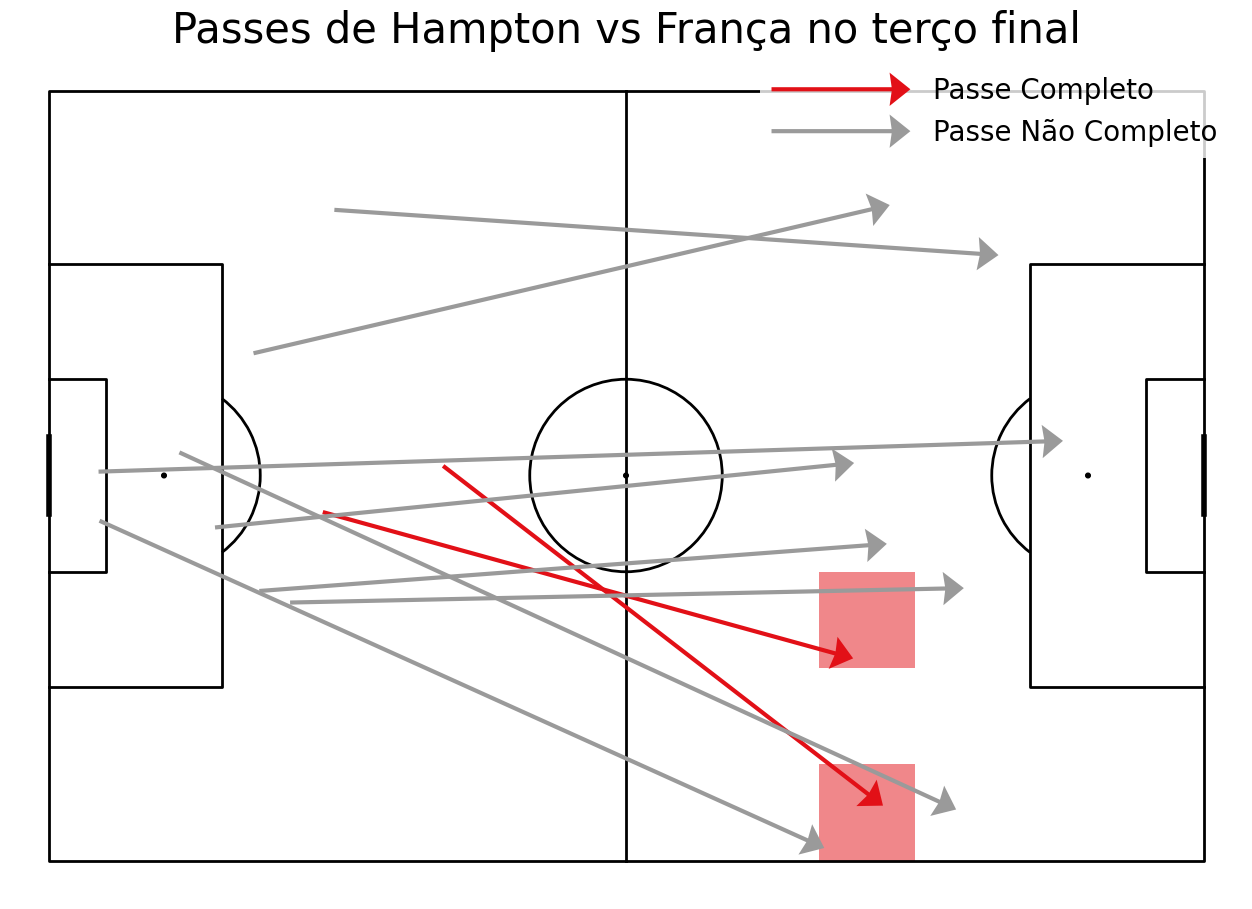

In [39]:
# Escolha o jogador para analisar; para repetir o mesmo gráfico com outro jogador, basta trocar o nome
passMap_f3('Hampton')

## Pass Network - Rede de passes

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

from mplsoccer import Pitch, FontManager, Sbopen

In [41]:
parser = Sbopen()
events, related, freeze, players = parser.event(4020846)
TEAM = "England Women's"
OPPONENT = "versus Spain Women's, 2025 Euro"

In [42]:
events.loc[events.tactics_formation.notnull(), 'tactics_id'] = events.loc[
    events.tactics_formation.notnull(), 'id']
events[['tactics_id', 'tactics_formation']] = events.groupby('team_name')[[
    'tactics_id', 'tactics_formation']].ffill()

In [43]:
formation_dict = {1: 'GK', 2: 'RB', 3: 'RCB', 4: 'CB', 5: 'LCB', 6: 'LB', 7: 'RWB',
                  8: 'LWB', 9: 'RDM', 10: 'CDM', 11: 'LDM', 12: 'RM', 13: 'RCM',
                  14: 'CM', 15: 'LCM', 16: 'LM', 17: 'RW', 18: 'RAM', 19: 'CAM',
                  20: 'LAM', 21: 'LW', 22: 'RCF', 23: 'ST', 24: 'LCF', 25: 'SS'}
players['position_abbreviation'] = players.position_id.map(formation_dict)

In [44]:
sub = events.loc[events.type_name == 'Substitution',
                 ['tactics_id', 'player_id', 'substitution_replacement_id',
                  'substitution_replacement_name']]
players_sub = players.merge(sub.rename({'tactics_id': 'id'}, axis='columns'),
                            on=['id', 'player_id'], how='inner', validate='1:1')
players_sub = (players_sub[['id', 'substitution_replacement_id', 'position_abbreviation']]
               .rename({'substitution_replacement_id': 'player_id'}, axis='columns'))
players = pd.concat([players, players_sub])
players.rename({'id': 'tactics_id'}, axis='columns', inplace=True)
players = players[['tactics_id', 'player_id', 'position_abbreviation']]

In [45]:
# add on the position the player was playing in the formation to the events dataframe
events = events.merge(players, on=['tactics_id', 'player_id'], how='left', validate='m:1')
# add on the position the receipient was playing in the formation to the events dataframe
events = events.merge(players.rename({'player_id': 'pass_recipient_id'},
                                     axis='columns'), on=['tactics_id', 'pass_recipient_id'],
                      how='left', validate='m:1', suffixes=['', '_receipt'])

In [46]:
events.groupby('team_name').tactics_formation.unique()

team_name
England Women's    [4231]
Spain Women's       [433]
Name: tactics_formation, dtype: object

In [47]:
FORMATION = '4231'
pass_cols = ['id', 'position_abbreviation', 'position_abbreviation_receipt']
passes_formation = events.loc[(events.team_name == TEAM) & (events.type_name == 'Pass') &
                              (events.tactics_formation == FORMATION) &
                              (events.position_abbreviation_receipt.notnull()), pass_cols].copy()
location_cols = ['position_abbreviation', 'x', 'y']
location_formation = events.loc[(events.team_name == TEAM) &
                                (events.type_name.isin(['Pass', 'Ball Receipt'])) &
                                (events.tactics_formation == FORMATION), location_cols].copy()

# average locations
average_locs_and_count = (location_formation.groupby('position_abbreviation')
                          .agg({'x': ['mean'], 'y': ['mean', 'count']}))
average_locs_and_count.columns = ['x', 'y', 'count']

# calculate the number of passes between each position (using min/ max so we get passes both ways)
passes_formation['pos_max'] = (passes_formation[['position_abbreviation',
                                                'position_abbreviation_receipt']]
                               .max(axis='columns'))
passes_formation['pos_min'] = (passes_formation[['position_abbreviation',
                                                'position_abbreviation_receipt']]
                               .min(axis='columns'))
passes_between = passes_formation.groupby(['pos_min', 'pos_max']).id.count().reset_index()
passes_between.rename({'id': 'pass_count'}, axis='columns', inplace=True)

# add on the location of each player so we have the start and end positions of the lines
passes_between = passes_between.merge(average_locs_and_count, left_on='pos_min', right_index=True)
passes_between = passes_between.merge(average_locs_and_count, left_on='pos_max', right_index=True,
                                      suffixes=['', '_end'])

In [48]:
MAX_LINE_WIDTH = 18
MAX_MARKER_SIZE = 3000
passes_between['width'] = (passes_between.pass_count / passes_between.pass_count.max() *
                           MAX_LINE_WIDTH)
average_locs_and_count['marker_size'] = (average_locs_and_count['count']
                                         / average_locs_and_count['count'].max() * MAX_MARKER_SIZE)

In [49]:
MIN_TRANSPARENCY = 0.3
color = np.array(to_rgba('white'))
color = np.tile(color, (len(passes_between), 1))
c_transparency = passes_between.pass_count / passes_between.pass_count.max()
c_transparency = (c_transparency * (1 - MIN_TRANSPARENCY)) + MIN_TRANSPARENCY
color[:, 3] = c_transparency

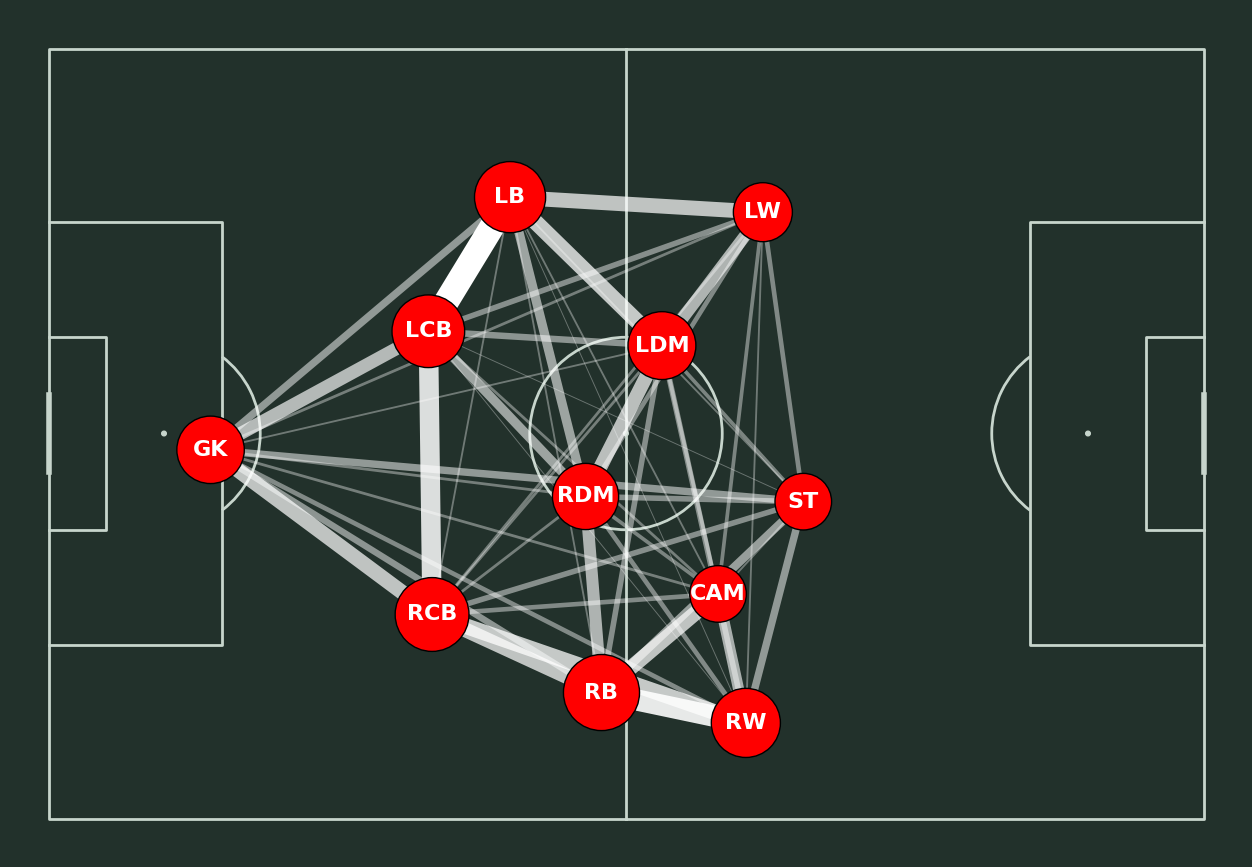

In [50]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor("#22312b")
pass_lines = pitch.lines(passes_between.x, passes_between.y,
                         passes_between.x_end, passes_between.y_end, lw=passes_between.width,
                         color=color, zorder=1, ax=ax)
pass_nodes = pitch.scatter(average_locs_and_count.x, average_locs_and_count.y,
                           s=average_locs_and_count.marker_size,
                           color='red', edgecolors='black', linewidth=1, alpha=1, ax=ax)
for index, row in average_locs_and_count.iterrows():
    pitch.annotate(row.name, xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=16, weight='bold', ax=ax)

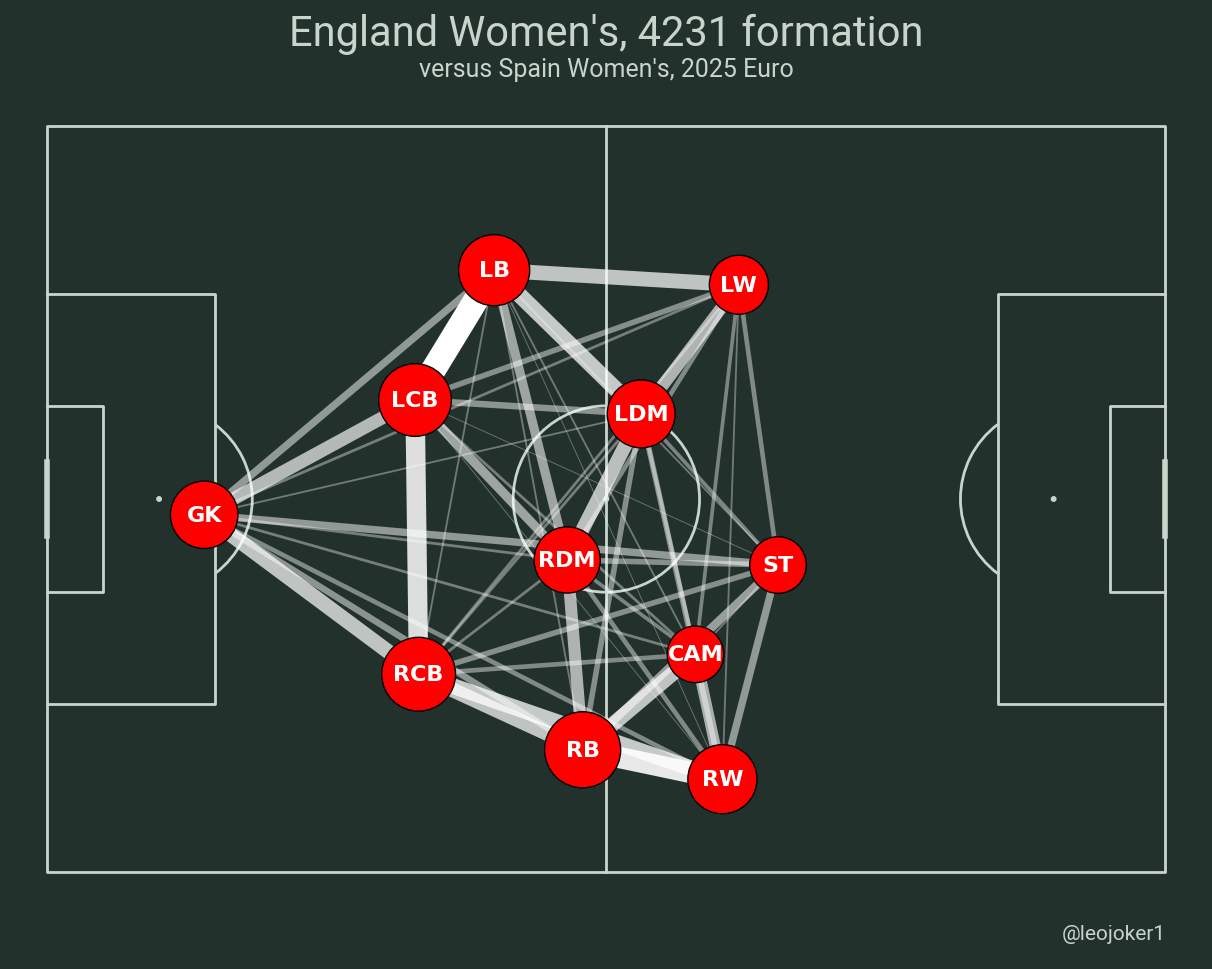

In [51]:
fig, axs = pitch.grid(figheight=10, title_height=0.08, endnote_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                      axis=False,
                      title_space=0, grid_height=0.82, endnote_height=0.05)
fig.set_facecolor("#22312b")
pass_lines = pitch.lines(passes_between.x, passes_between.y,
                         passes_between.x_end, passes_between.y_end, lw=passes_between.width,
                         color=color, zorder=1, ax=axs['pitch'])
pass_nodes = pitch.scatter(average_locs_and_count.x, average_locs_and_count.y,
                           s=average_locs_and_count.marker_size,
                           color='red', edgecolors='black', linewidth=1, alpha=1, ax=axs['pitch'])
for index, row in average_locs_and_count.iterrows():
    pitch.annotate(row.name, xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=16, weight='bold', ax=axs['pitch'])

# Load a custom font.
URL = 'https://raw.githubusercontent.com/googlefonts/roboto/main/src/hinted/Roboto-Regular.ttf'
robotto_regular = FontManager(URL)

# endnote /title
axs['endnote'].text(1, 0.5, '@leojoker1', color='#c7d5cc',
                    va='center', ha='right', fontsize=15,
                    fontproperties=robotto_regular.prop)
TITLE_TEXT = f'{TEAM}, {FORMATION} formation'
axs['title'].text(0.5, 0.7, TITLE_TEXT, color='#c7d5cc',
                  va='center', ha='center', fontproperties=robotto_regular.prop, fontsize=30)
axs['title'].text(0.5, 0.25, OPPONENT, color='#c7d5cc',
                  va='center', ha='center', fontproperties=robotto_regular.prop, fontsize=18)

# sphinx_gallery_thumbnail_path = 'gallery/pitch_plots/images/sphx_glr_plot_pass_network_002.png'

plt.show()  # If you are using a Jupyter notebook you do not need this line

## Tema alternativo

In [52]:
import matplotlib.patheffects as path_effects

In [53]:
URL = "https://raw.githubusercontent.com/google/fonts/main/ofl/oswald/Oswald%5Bwght%5D.ttf"
oswald_regular = FontManager(URL)

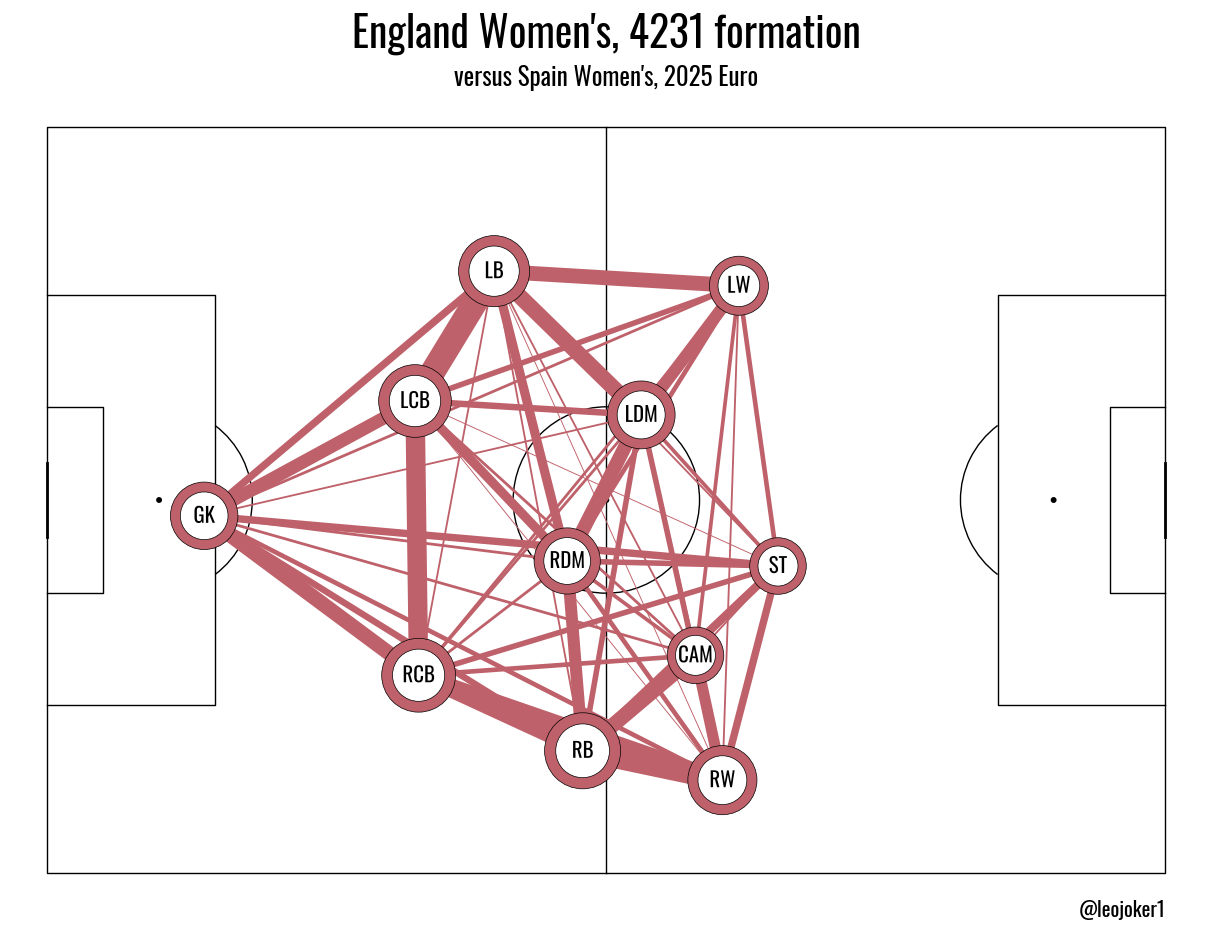

In [54]:
pitch = Pitch(
    pitch_type="statsbomb", pitch_color="white", line_color="black", linewidth=1,
)
fig, axs = pitch.grid(
    figheight=10,
    title_height=0.08,
    endnote_space=0,
    # Turn off the endnote/title axis. I usually do this after
    # I am happy with the chart layout and text placement
    axis=False,
    title_space=0,
    grid_height=0.82,
    endnote_height=0.01,
)
fig.set_facecolor("white")
pass_lines = pitch.lines(
    passes_between.x,
    passes_between.y,
    passes_between.x_end,
    passes_between.y_end,
    lw=passes_between.width,
    color="#BF616A",
    zorder=1,
    ax=axs["pitch"],
)
pass_nodes = pitch.scatter(
    average_locs_and_count.x,
    average_locs_and_count.y,
    s=average_locs_and_count.marker_size,
    color="#BF616A",
    edgecolors="black",
    linewidth=0.5,
    alpha=1,
    ax=axs["pitch"],
)
pass_nodes_internal = pitch.scatter(
    average_locs_and_count.x,
    average_locs_and_count.y,
    s=average_locs_and_count.marker_size / 2,
    color="white",
    edgecolors="black",
    linewidth=0.5,
    alpha=1,
    ax=axs["pitch"],
)
for index, row in average_locs_and_count.iterrows():
    text = pitch.annotate(
        row.name,
        xy=(row.x, row.y),
        c="black",
        va="center",
        ha="center",
        size=15,
        weight="bold",
        ax=axs["pitch"],
        fontproperties=oswald_regular.prop,
    )
    text.set_path_effects([path_effects.withStroke(linewidth=1, foreground="white")])

axs["endnote"].text(
    1,
    1,
    "@leojoker1",
    color="black",
    va="center",
    ha="right",
    fontsize=15,
    fontproperties=oswald_regular.prop,
)
TITLE_TEXT = f"{TEAM}, {FORMATION} formation"
axs["title"].text(
    0.5,
    0.7,
    TITLE_TEXT,
    color="black",
    va="center",
    ha="center",
    fontproperties=oswald_regular.prop,
    fontsize=30,
)
axs["title"].text(
    0.5,
    0.15,
    OPPONENT,
    color="black",
    va="center",
    ha="center",
    fontproperties=oswald_regular.prop,
    fontsize=18,
)

plt.show()  # If you are using a Jupyter notebook you do not need this line